In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

from config.settings import *

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from google.oauth2 import service_account
from google.cloud import bigquery

print("Project root:", PROJECT_ROOT)
print("BigQuery table:", BQ_TABLE_MAIN)

/opt/anaconda3/envs/envhealth/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Project root: /Users/yongyili/EnvHealthLondon
BigQuery table: env-health-london-2026.env_health.master_borough


In [2]:
creds = service_account.Credentials.from_service_account_file(KEY_PATH)

bq_client = bigquery.Client(
    credentials=creds,
    project=GCP_PROJECT
)

print("BigQuery client ready")

BigQuery client ready


In [3]:
query = f"""
SELECT *
FROM `{BQ_TABLE_MAIN}`
"""

df = bq_client.query(query).to_dataframe()

print(df.shape)
df.head()

(33, 12)


,borough_name,no2_baseline_mean,no2_imputed,no2_source_borough,lden_mean,green_area_m2,imd_score_mean,imd_rank_mean,imd_decile_mean,pct_most_deprived,borough_area_m2,green_space_share_pct
0,Bexley,26.685649,False,Bexley,63.082413,8.659319e+06,15.882363,19696.109589,6.506849,0.0,6.058023e+07,14.293968
1,Camden,53.645008,False,Camden,64.701372,6.431268e+06,19.981053,16247.744361,5.406015,0.0,2.178930e+07,29.515721
2,City of London,59.732950,False,City of London,64.333843,5.145284e+04,14.805000,20275.166667,6.666667,0.0,2.903926e+06,1.771837
3,Harrow,30.330853,False,Harrow,63.580240,6.029958e+06,14.860883,19977.000000,6.554745,0.0,5.046330e+07,11.949195
4,Hillingdon,37.919454,False,Hillingdon,61.948496,1.246287e+07,17.839329,17705.385093,5.906832,0.0,1.157005e+08,10.771660


In [ ]:
# Basic quality checks

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borough_name           33 non-null     object 
 1   no2_baseline_mean      33 non-null     float64
 2   no2_imputed            33 non-null     boolean
 3   no2_source_borough     33 non-null     object 
 4   lden_mean              33 non-null     float64
 5   green_area_m2          33 non-null     float64
 6   imd_score_mean         33 non-null     float64
 7   imd_rank_mean          33 non-null     float64
 8   imd_decile_mean        33 non-null     float64
 9   pct_most_deprived      33 non-null     float64
 10  borough_area_m2        33 non-null     float64
 11  green_space_share_pct  33 non-null     float64
dtypes: boolean(1), float64(9), object(2)
memory usage: 3.0+ KB


In [17]:
df.isnull().sum()

borough_name             0
no2_baseline_mean        0
no2_imputed              0
no2_source_borough       0
lden_mean                0
green_area_m2            0
imd_score_mean           0
imd_rank_mean            0
imd_decile_mean          0
pct_most_deprived        0
borough_area_m2          0
green_space_share_pct    0
dtype: int64

In [18]:
df.describe()

,no2_baseline_mean,lden_mean,green_area_m2,imd_score_mean,imd_rank_mean,imd_decile_mean,pct_most_deprived,borough_area_m2,green_space_share_pct
count,33.000000,33.000000,3.300000e+01,33.000000,33.000000,33.000000,33.000000,3.300000e+01,33.000000
mean,38.958277,63.685835,9.775805e+06,21.210097,15449.088440,5.198971,2.197838,4.767881e+07,21.175585
std,9.868795,0.658738,6.760462e+06,6.175374,4809.358985,1.467078,2.969160,3.275213e+07,12.324287
min,23.116494,61.948496,5.145284e+04,9.423122,7244.500000,2.681818,0.000000,2.903926e+06,1.771837
25%,30.330853,63.244526,5.075754e+06,15.953626,11546.481928,4.024096,0.000000,2.681004e+07,14.293968
50%,37.919454,63.611480,8.659319e+06,21.957305,14926.636364,5.022727,0.826446,3.762474e+07,18.251368
75%,46.512597,64.076461,1.354176e+07,25.797247,19287.450237,6.383886,2.958580,5.641922e+07,21.508725
max,59.732950,65.275871,2.858851e+07,32.883473,25694.460870,8.321739,11.111111,1.501349e+08,62.051331


In [19]:
# Add borough area and green-space shareboroughs = gpd.read_file(f"{DATA_DIR}/London_Borough_Excluding_MHW.shp")

In [20]:
boroughs = gpd.read_file(f"{DATA_DIR}/London_Borough_Excluding_MHW.shp")

boroughs = boroughs[["GSS_CODE", "NAME", "geometry"]].rename(
    columns={
        "GSS_CODE": "borough_code",
        "NAME": "borough_name"
    }
)

boroughs = boroughs.to_crs("EPSG:27700")

boroughs["borough_area_m2"] = boroughs.geometry.area

borough_area = boroughs[["borough_name", "borough_area_m2"]]

borough_area.head()

,borough_name,borough_area_m2
0,Kingston upon Thames,3.726118e+07
1,Croydon,8.649444e+07
2,Bromley,1.501349e+08
3,Hounslow,5.592623e+07
4,Ealing,5.554435e+07


In [23]:
df = df.merge(borough_area, on="borough_name", how="left")

df["green_space_share_pct"] = (
    df["green_area_m2"] / df["borough_area_m2"] * 100
)

df[["borough_name", "green_area_m2", "borough_area_m2", "green_space_share_pct"]].head()

,borough_name,green_area_m2,borough_area_m2,green_space_share_pct
0,Bexley,8.659319e+06,6.058023e+07,14.293968
1,Camden,6.431268e+06,2.178930e+07,29.515721
2,City of London,5.145284e+04,2.903926e+06,1.771837
3,Harrow,6.029958e+06,5.046330e+07,11.949195
4,Hillingdon,1.246287e+07,1.157005e+08,10.771660


In [24]:
df["green_space_share_pct"].describe()

count    33.000000
mean     21.175585
std      12.324287
min       1.771837
25%      14.293968
50%      18.251368
75%      21.508725
max      62.051331
Name: green_space_share_pct, dtype: float64

In [41]:
eda_cols = [
    "no2_baseline_mean",
    "lden_mean",
    "major_road_density_km_per_km2",
    "green_space_share_pct",
    "imd_score_mean",
    "pct_most_deprived"
]

df[eda_cols].describe().round(2)

,no2_baseline_mean,lden_mean,major_road_density_km_per_km2,green_space_share_pct,imd_score_mean,pct_most_deprived
count,33.00,33.00,33.00,33.00,33.00,33.00
mean,38.96,63.69,2.13,21.18,21.21,2.20
std,9.87,0.66,1.02,12.32,6.18,2.97
min,23.12,61.95,0.84,1.77,9.42,0.00
25%,30.33,63.24,1.43,14.29,15.95,0.00
50%,37.92,63.61,1.80,18.25,21.96,0.83
75%,46.51,64.08,2.63,21.51,25.80,2.96
max,59.73,65.28,5.20,62.05,32.88,11.11


In [26]:
#Highest NO2
df[["borough_name", "no2_baseline_mean", "no2_imputed", "no2_source_borough"]] \
    .sort_values("no2_baseline_mean", ascending=False) \
    .head(10)

,borough_name,no2_baseline_mean,no2_imputed,no2_source_borough
2,City of London,59.732950,False,City of London
18,Westminster,55.780984,False,Westminster
6,Lambeth,53.645176,False,Lambeth
1,Camden,53.645008,False,Camden
7,Merton,49.373426,False,Merton
32,Waltham Forest,48.655825,True,Hackney
28,Hackney,48.655825,False,Hackney
10,Wandsworth,47.721441,False,Wandsworth
29,Barnet,46.512597,True,Brent
25,Brent,46.512597,False,Brent


In [27]:
#Highest noise
df[["borough_name", "lden_mean"]] \
    .sort_values("lden_mean", ascending=False) \
    .head(10)

,borough_name,lden_mean
26,Kensington and Chelsea,65.275871
1,Camden,64.701372
18,Westminster,64.560049
23,Islington,64.512417
31,Hammersmith and Fulham,64.414354
10,Wandsworth,64.372772
2,City of London,64.333843
21,Southwark,64.135170
25,Brent,64.076461
27,Haringey,64.065944


In [28]:
#Lowest Greenspace share
df[["borough_name", "green_space_share_pct"]] \
    .sort_values("green_space_share_pct", ascending=True) \
    .head(10)

,borough_name,green_space_share_pct
2,City of London,1.771837
23,Islington,7.407340
4,Hillingdon,10.771660
3,Harrow,11.949195
15,Tower Hamlets,12.149727
11,Bromley,12.379638
32,Waltham Forest,13.894715
31,Hammersmith and Fulham,14.116682
0,Bexley,14.293968
6,Lambeth,14.422164


In [29]:
#Highest deprivation score
df[["borough_name", "imd_score_mean", "pct_most_deprived"]] \
    .sort_values("imd_score_mean", ascending=False) \
    .head(10)

,borough_name,imd_score_mean,pct_most_deprived
22,Barking and Dagenham,32.883473,3.636364
28,Hackney,32.868201,11.111111
19,Newham,29.771079,2.439024
15,Tower Hamlets,27.970458,1.388889
23,Islington,27.706041,4.878049
27,Haringey,27.587200,9.655172
20,Lewisham,26.869361,2.958580
21,Southwark,26.041289,3.012048
6,Lambeth,25.797247,0.000000
24,Enfield,25.403448,5.464481


In [ ]:
#Distribution plots

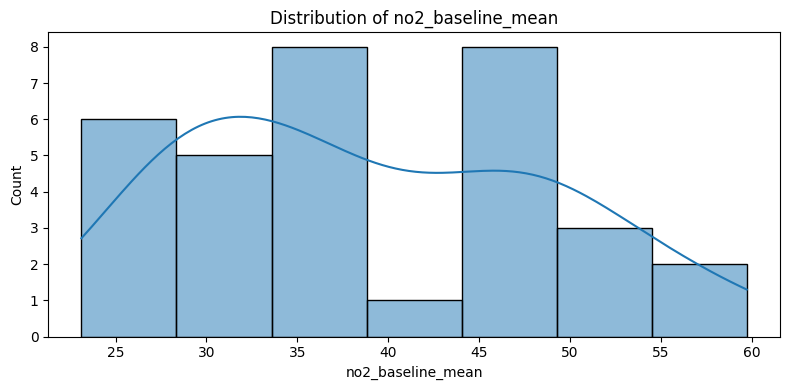

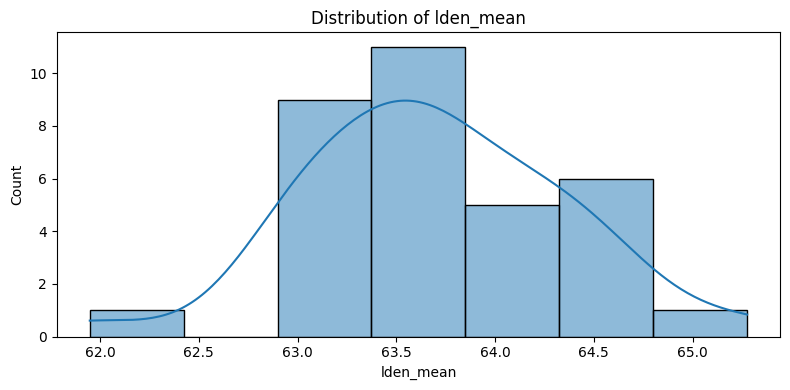

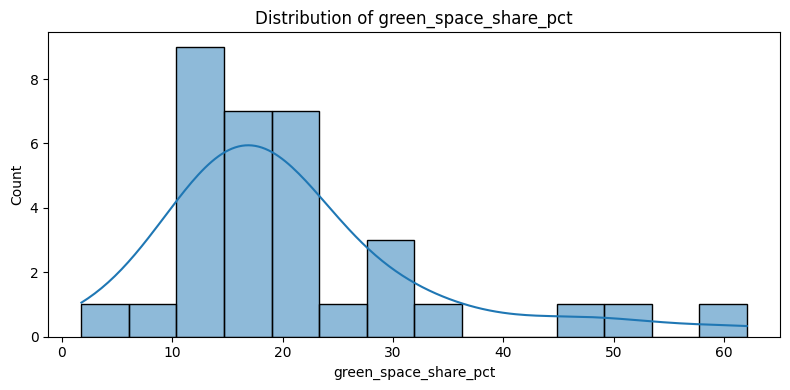

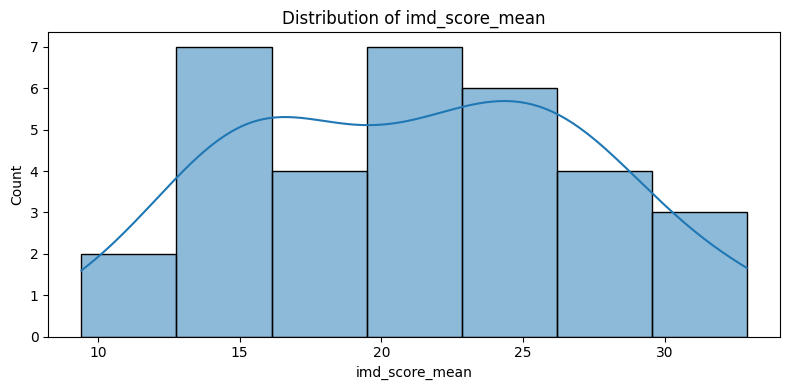

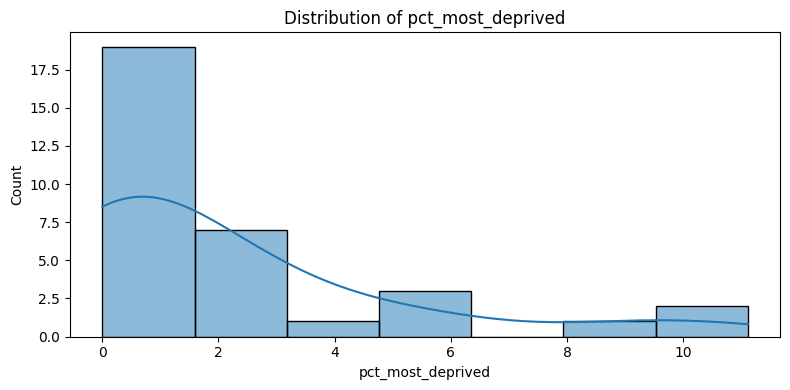

In [15]:
for col in eda_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [ ]:
# Correlation Matrix
#Use Spearman correlation because borough-level environmental data may not be normally distributed and the sample size is only 33.

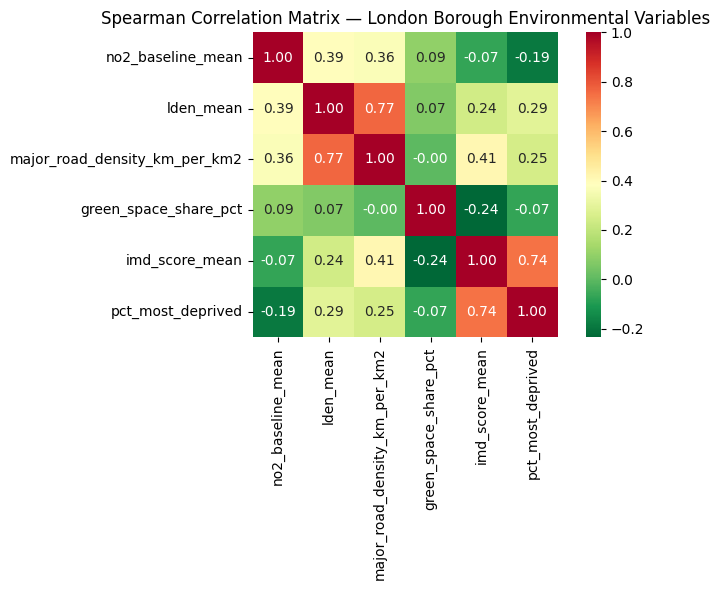

In [42]:
corr = df[eda_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    square=True
)

plt.title("Spearman Correlation Matrix — London Borough Environmental Variables")
plt.tight_layout()
plt.show()

In [20]:
df[eda_cols].describe().round(2)
corr

,no2_baseline_mean,lden_mean,green_space_share_pct,imd_score_mean,pct_most_deprived
no2_baseline_mean,1.000000,0.388165,0.094283,-0.070211,-0.187872
lden_mean,0.388165,1.000000,0.067179,0.240307,0.287078
green_space_share_pct,0.094283,0.067179,1.000000,-0.235294,-0.068449
imd_score_mean,-0.070211,0.240307,-0.235294,1.000000,0.744087
pct_most_deprived,-0.187872,0.287078,-0.068449,0.744087,1.000000


In [ ]:
# EDA scatter plots

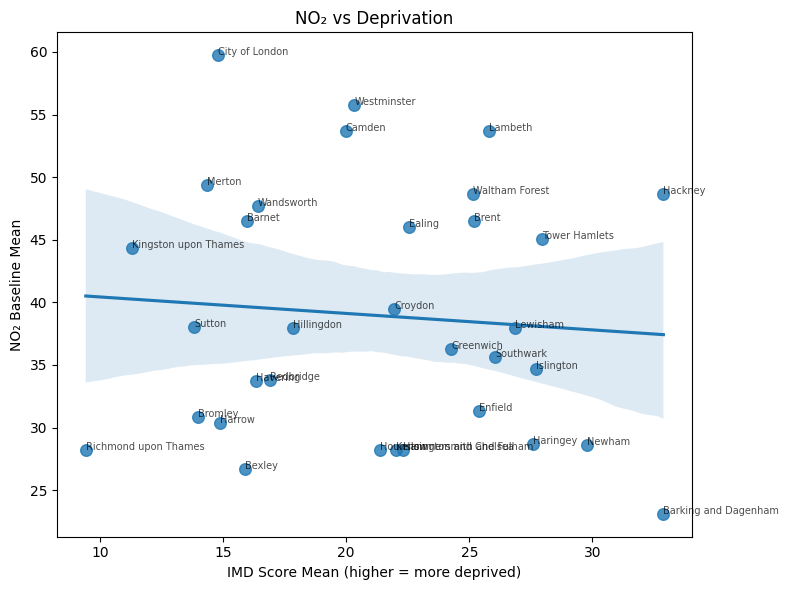

In [17]:
# NO₂ vs deprivation
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x="imd_score_mean",
    y="no2_baseline_mean",
    scatter_kws={"s": 70}
)

for _, row in df.iterrows():
    plt.text(
        row["imd_score_mean"],
        row["no2_baseline_mean"],
        row["borough_name"],
        fontsize=7,
        alpha=0.7
    )

plt.xlabel("IMD Score Mean (higher = more deprived)")
plt.ylabel("NO₂ Baseline Mean")
plt.title("NO₂ vs Deprivation")
plt.tight_layout()
plt.show()

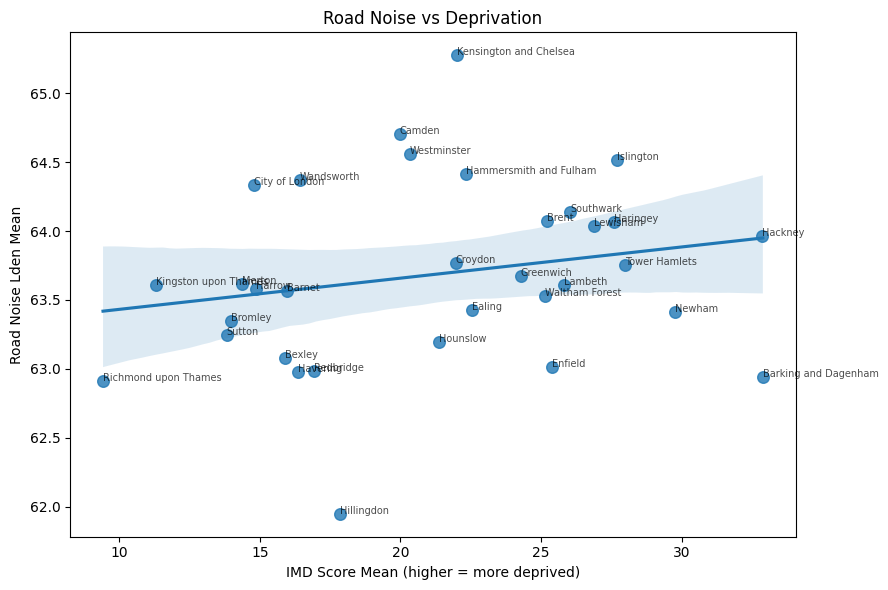

In [23]:
# Noise vs deprivation
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="imd_score_mean",
    y="lden_mean",
    scatter_kws={"s": 70}
)

for _, row in df.iterrows():
    plt.text(
        row["imd_score_mean"],
        row["lden_mean"],
        row["borough_name"],
        fontsize=7,
        alpha=0.7
    )

plt.xlabel("IMD Score Mean (higher = more deprived)")
plt.ylabel("Road Noise Lden Mean")
plt.title("Road Noise vs Deprivation")
plt.tight_layout()
plt.show()

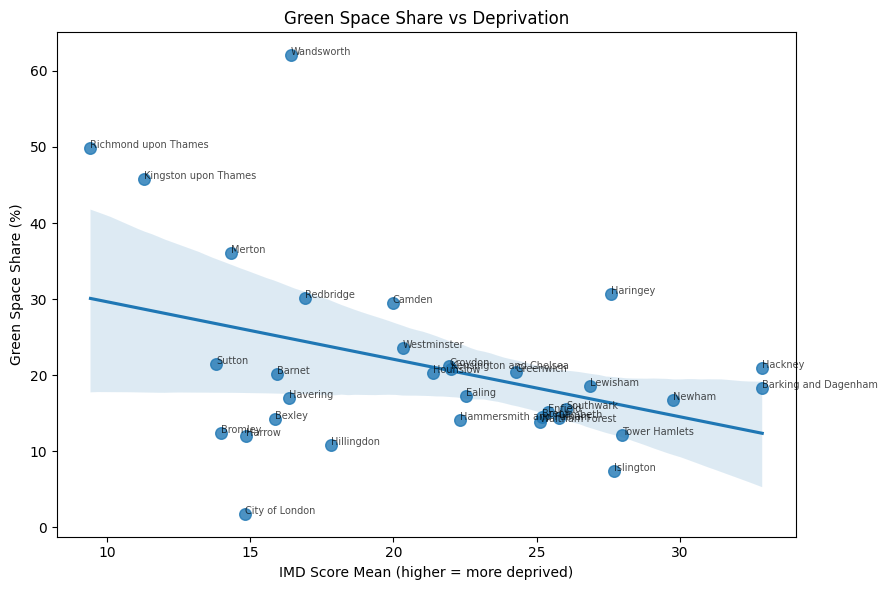

In [24]:
# Green-space share vs deprivation
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="imd_score_mean",
    y="green_space_share_pct",
    scatter_kws={"s": 70}
)

for _, row in df.iterrows():
    plt.text(
        row["imd_score_mean"],
        row["green_space_share_pct"],
        row["borough_name"],
        fontsize=7,
        alpha=0.7
    )

plt.xlabel("IMD Score Mean (higher = more deprived)")
plt.ylabel("Green Space Share (%)")
plt.title("Green Space Share vs Deprivation")
plt.tight_layout()
plt.show()

In [25]:
df.to_parquet(f"{DATA_DIR}/master_borough_eda.parquet")

print(f"Saved EDA-ready table to {DATA_DIR}/master_borough_eda.parquet")

Saved EDA-ready table to /Users/yongyili/EnvHealthLondon/data/master_borough_eda.parquet


In [26]:
job = bq_client.load_table_from_dataframe(
    df,
    BQ_TABLE_MAIN,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Updated BigQuery table with green_space_share_pct: {BQ_TABLE_MAIN}")

Updated BigQuery table with green_space_share_pct: env-health-london-2026.env_health.master_borough


In [ ]:
# Measure road density use OS open roads

In [4]:
roads = gpd.read_file(f"{DATA_DIR}/os_open_roads.gpkg")

In [5]:
import fiona

fiona.listlayers(f"{DATA_DIR}/os_open_roads.gpkg")

['motorway_junction', 'road_link', 'road_node']

In [6]:
import geopandas as gpd

# Load London borough boundaries
boroughs = gpd.read_file(f"{DATA_DIR}/London_Borough_Excluding_MHW.shp")
boroughs = boroughs.to_crs("EPSG:27700")

# London bounding box
bbox = tuple(boroughs.total_bounds)
print("London bbox:", bbox)

# Load only roads inside London bbox
roads = gpd.read_file(
    f"{DATA_DIR}/os_open_roads.gpkg",
    layer="road_link",
    bbox=bbox
)

print("Loaded roads:", roads.shape)
print(roads.columns)
print(roads.crs)

roads.head()

London bbox: (503568.1999689172, 155850.79992321326, 561957.4999513933, 200933.89990968409)
Loaded roads: (264596, 21)
Index(['id', 'fictitious', 'road_classification', 'road_function',
       'form_of_way', 'road_classification_number', 'name_1', 'name_1_lang',
       'name_2', 'name_2_lang', 'road_structure', 'length', 'length_uom',
       'loop', 'primary_route', 'trunk_road', 'start_node', 'end_node',
       'road_number_toid', 'road_name_toid', 'geometry'],
      dtype='object')
EPSG:27700


,id,fictitious,road_classification,road_function,form_of_way,road_classification_number,name_1,name_1_lang,name_2,name_2_lang,...,length,length_uom,loop,primary_route,trunk_road,start_node,end_node,road_number_toid,road_name_toid,geometry
0,05A25472-DEEC-4DB0-9B89-7469BF9D8C84,False,Unknown,Restricted Local Access Road,Single Carriageway,None,None,None,None,None,...,118.0,m,False,False,False,F7837AF4-6128-44D3-9898-E65934820640,D555A92F-E432-44C9-B2BA-64669259BB53,None,None,"LINESTRING (503578.500 162363.990, 503574.580 ..."
1,7F5040E1-BDDA-485D-8ADB-36391991D803,False,Unclassified,Minor Road,Single Carriageway,None,Woodham Park Road,None,None,None,...,90.0,m,False,False,False,AEE35B77-E414-4619-8D6F-591B41DC15C5,F7837AF4-6128-44D3-9898-E65934820640,None,osgb4000000030482751,"LINESTRING (503511.390 162422.330, 503548.100 ..."
2,30E57578-8BAB-47F8-94A1-964A8A71FB1A,False,Unknown,Restricted Local Access Road,Single Carriageway,None,None,None,None,None,...,69.0,m,False,False,False,17C30814-7BD8-4EAA-9C94-F369FB09E5EA,E2BA794F-0FB7-4926-9A76-7112AE80A374,None,None,"LINESTRING (503582.020 162356.960, 503557.020 ..."
3,724CEE6F-3B9E-4151-97C1-641BD031D34D,False,Unclassified,Local Road,Single Carriageway,None,Langshott Close,None,None,None,...,39.0,m,False,False,False,67166D05-50B2-46FE-812A-80E12CA1138B,C024C12C-319E-4309-B0B1-B5CE953AA322,None,osgb4000000030541077,"LINESTRING (503577.000 161822.000, 503560.500 ..."
4,5BF8A0B2-0930-493D-90F6-6F0535764493,False,Not Classified,Restricted Local Access Road,Single Carriageway,None,Brox Lane,None,None,None,...,18.0,m,False,False,False,BA1A678F-0FF6-486A-8306-98DB1229ACD8,80A50E6F-72BE-49DB-BAE8-DE6261F658B3,None,osgb4000000030482752,"LINESTRING (503579.000 162884.000, 503570.000 ..."


In [7]:
roads = roads.to_crs("EPSG:27700")
roads.to_parquet(f"{DATA_DIR}/roads_london.parquet")

print("Saved London roads subset")

Saved London roads subset


In [8]:
roads["road_classification"].value_counts(dropna=False)

road_classification
Unclassified             143461
Unknown                   45446
A Road                    30363
Not Classified            23143
Classified Unnumbered     12593
B Road                     9093
Motorway                    497
Name: count, dtype: int64

In [9]:
roads["road_function"].value_counts(dropna=False)

road_function
Local Road                      139892
Restricted Local Access Road     37214
A Road                           30363
Minor Road                       27598
Secondary Access Road            17165
B Road                            9093
Local Access Road                 2774
Motorway                           497
Name: count, dtype: int64

In [10]:
roads = roads.to_crs("EPSG:27700")
boroughs = boroughs.to_crs("EPSG:27700")

In [11]:
roads_london = gpd.clip(roads, boroughs).copy()

print(roads_london.shape)
roads_london.head()

(211336, 21)


,id,fictitious,road_classification,road_function,form_of_way,road_classification_number,name_1,name_1_lang,name_2,name_2_lang,...,length,length_uom,loop,primary_route,trunk_road,start_node,end_node,road_number_toid,road_name_toid,geometry
13698,82F7FE1B-4412-4345-964C-B2AC22457E62,False,A Road,A Road,Single Carriageway,A243,Leatherhead Road,None,None,None,...,635.0,m,False,True,False,7CE91E03-F52C-43B9-B16A-50E7EF08B952,DB23300F-0B12-466D-AD62-1597AD7FCE1F,osgb4000000030575904,osgb4000000030480801,"LINESTRING (516792.070 160261.470, 516871.000 ..."
13700,AA0D0AD4-E977-4FC0-82B0-AB06E2B6A3F2,False,Not Classified,Restricted Local Access Road,Single Carriageway,None,None,None,None,None,...,359.0,m,False,False,False,DB23300F-0B12-466D-AD62-1597AD7FCE1F,C50859A8-9500-494A-B003-AA258295F986,None,None,"LINESTRING (517014.830 160855.860, 517059.290 ..."
13731,F1CE5CC6-9EF3-4124-9652-2578EF9BB055,False,A Road,A Road,Single Carriageway,A243,Leatherhead Road,None,None,None,...,124.0,m,False,True,False,DB23300F-0B12-466D-AD62-1597AD7FCE1F,6822E5FF-1EA9-4C57-86F1-D71C666C421B,osgb4000000030575904,osgb4000000030480801,"LINESTRING (517014.830 160855.860, 517035.200 ..."
13701,320AD08D-2C8B-4450-AF68-BA63486FB60C,False,Unknown,Restricted Local Access Road,Single Carriageway,None,Leatherhead Road,None,None,None,...,46.0,m,False,False,False,6822E5FF-1EA9-4C57-86F1-D71C666C421B,14FA26F3-5432-45EB-8405-1FABB4DF23D7,None,osgb4000000030480801,"LINESTRING (517055.570 160972.830, 517077.330 ..."
13732,FC45E65D-F556-4CBD-BD95-F67974A1D2FD,False,A Road,A Road,Single Carriageway,A243,Leatherhead Road,None,None,None,...,13.0,m,False,True,False,6822E5FF-1EA9-4C57-86F1-D71C666C421B,312755D3-48E7-4DA7-B502-0896B7791136,osgb4000000030575904,osgb4000000030480801,"LINESTRING (517055.570 160972.830, 517057.130 ..."


In [12]:
roads_london["road_length_m"] = roads_london.geometry.length

In [14]:
boroughs["borough_area_m2"] = boroughs.geometry.area

In [22]:
roads_joined = gpd.sjoin(
    roads_london[["road_length_m", "road_classification", "road_function", "primary_route", "trunk_road", "geometry"]],
    boroughs[["borough_name", "borough_area_m2", "geometry"]],
    how="inner",
    predicate="intersects"
)

roads_joined.head()

,road_length_m,road_classification,road_function,primary_route,trunk_road,geometry,index_right,borough_name,borough_area_m2
13698,634.939294,A Road,A Road,True,False,"LINESTRING (516792.070 160261.470, 516871.000 ...",0,Kingston upon Thames,3.726118e+07
13700,358.624750,Not Classified,Restricted Local Access Road,False,False,"LINESTRING (517014.830 160855.860, 517059.290 ...",0,Kingston upon Thames,3.726118e+07
13731,123.861731,A Road,A Road,True,False,"LINESTRING (517014.830 160855.860, 517035.200 ...",0,Kingston upon Thames,3.726118e+07
13701,46.289128,Unknown,Restricted Local Access Road,False,False,"LINESTRING (517055.570 160972.830, 517077.330 ...",0,Kingston upon Thames,3.726118e+07
13732,13.019370,A Road,A Road,True,False,"LINESTRING (517055.570 160972.830, 517057.130 ...",0,Kingston upon Thames,3.726118e+07


In [30]:
road_borough = (
    roads_joined
    .groupby("borough_name")
    .agg(
        total_road_length_m=("road_length_m", "sum"),
        borough_area_m2=("borough_area_m2", "first")
    )
    .reset_index()
)

road_borough["road_density_km_per_km2"] = (
    (road_borough["total_road_length_m"] / 1000) /
    (road_borough["borough_area_m2"] / 1_000_000)
)

road_borough.sort_values("road_density_km_per_km2", ascending=False).head(10)

,borough_name,total_road_length_m,borough_area_m2,road_density_km_per_km2
6,City of London,63231.423308,2.903926e+06,21.774464
19,Kensington and Chelsea,248536.663077,1.212385e+07,20.499817
18,Islington,285384.011707,1.485665e+07,19.209173
32,Westminster,404696.616732,2.148698e+07,18.834507
29,Tower Hamlets,362380.518848,1.977794e+07,18.322463
21,Lambeth,476751.329456,2.681004e+07,17.782566
11,Hackney,331357.004662,1.904903e+07,17.394956
12,Hammersmith and Fulham,279846.576771,1.639762e+07,17.066295
27,Southwark,476164.111005,2.886204e+07,16.497939
5,Camden,350139.277793,2.178930e+07,16.069325


In [31]:
major_roads = roads_london[
    (roads_london["primary_route"] == True) |
    (roads_london["trunk_road"] == True)
].copy()

print(major_roads.shape)

(6742, 22)


In [32]:
major_roads["major_road_length_m"] = major_roads.geometry.length

major_joined = gpd.sjoin(
    major_roads[["major_road_length_m", "geometry"]],
    boroughs[["borough_name", "borough_area_m2", "geometry"]],
    how="inner",
    predicate="intersects"
)

major_road_borough = (
    major_joined
    .groupby("borough_name")
    .agg(
        major_road_length_m=("major_road_length_m", "sum"),
        borough_area_m2=("borough_area_m2", "first")
    )
    .reset_index()
)

major_road_borough["major_road_density_km_per_km2"] = (
    (major_road_borough["major_road_length_m"] / 1000) /
    (major_road_borough["borough_area_m2"] / 1_000_000)
)

major_road_borough.sort_values("major_road_density_km_per_km2", ascending=False).head(10)

,borough_name,major_road_length_m,borough_area_m2,major_road_density_km_per_km2
19,Kensington and Chelsea,19958.584195,1.212385e+07,1.646225
21,Lambeth,30107.854872,2.681004e+07,1.123007
31,Wandsworth,38048.738631,3.426416e+07,1.110453
32,Westminster,23245.381278,2.148698e+07,1.081836
29,Tower Hamlets,21260.472979,1.977794e+07,1.074959
18,Islington,13527.724319,1.485665e+07,0.910550
17,Hounslow,44101.499834,5.592623e+07,0.788566
11,Hackney,14450.982638,1.904903e+07,0.758620
10,Greenwich,31393.498356,4.733407e+07,0.663233
1,Barnet,53782.945749,8.674831e+07,0.619988


In [33]:
road_borough.to_parquet(f"{DATA_DIR}/road_borough.parquet")

In [ ]:
# create major-road density properly

In [34]:
major_roads_london = roads_london[
    roads_london["road_classification"].isin(["A Road", "B Road", "Motorway"])
].copy()

print(major_roads_london.shape)
major_roads_london["road_classification"].value_counts()

(32624, 22)


road_classification
A Road      25563
B Road       6850
Motorway      211
Name: count, dtype: int64

In [35]:
major_roads_london["major_road_length_m"] = major_roads_london.geometry.length

In [36]:
major_roads_joined = gpd.sjoin(
    major_roads_london[["major_road_length_m", "road_classification", "geometry"]],
    boroughs[["borough_name", "borough_area_m2", "geometry"]],
    how="inner",
    predicate="intersects"
)

major_roads_joined.head()

,major_road_length_m,road_classification,geometry,index_right,borough_name,borough_area_m2
13698,634.939294,A Road,"LINESTRING (516792.070 160261.470, 516871.000 ...",0,Kingston upon Thames,3.726118e+07
13731,123.861731,A Road,"LINESTRING (517014.830 160855.860, 517035.200 ...",0,Kingston upon Thames,3.726118e+07
13732,13.019370,A Road,"LINESTRING (517055.570 160972.830, 517057.130 ...",0,Kingston upon Thames,3.726118e+07
13702,279.028401,A Road,"LINESTRING (517058.690 160985.470, 517096.100 ...",0,Kingston upon Thames,3.726118e+07
12672,345.139282,A Road,"LINESTRING (516650.720 159946.631, 516652.000 ...",0,Kingston upon Thames,3.726118e+07


In [37]:
major_road_borough = (
    major_roads_joined
    .groupby("borough_name")
    .agg(
        major_road_length_m=("major_road_length_m", "sum"),
        borough_area_m2=("borough_area_m2", "first")
    )
    .reset_index()
)

major_road_borough["major_road_density_km_per_km2"] = (
    (major_road_borough["major_road_length_m"] / 1000) /
    (major_road_borough["borough_area_m2"] / 1_000_000)
)

major_road_borough.sort_values("major_road_density_km_per_km2", ascending=False).head(10)

,borough_name,major_road_length_m,borough_area_m2,major_road_density_km_per_km2
6,City of London,15086.892551,2.903926e+06,5.195344
32,Westminster,88493.364874,2.148698e+07,4.118465
19,Kensington and Chelsea,47221.453517,1.212385e+07,3.894923
29,Tower Hamlets,75593.395065,1.977794e+07,3.822107
18,Islington,49045.166942,1.485665e+07,3.301226
5,Camden,65287.967756,2.178930e+07,2.996332
11,Hackney,54524.088429,1.904903e+07,2.862303
21,Lambeth,74706.169583,2.681004e+07,2.786500
27,Southwark,75986.981330,2.886204e+07,2.632766
12,Hammersmith and Fulham,40811.544583,1.639762e+07,2.488870


In [38]:
major_road_borough.to_parquet(f"{DATA_DIR}/major_road_borough.parquet")

In [39]:
df = df.merge(
    major_road_borough[["borough_name", "major_road_density_km_per_km2"]],
    on="borough_name",
    how="left"
)

df[["borough_name", "major_road_density_km_per_km2"]].head()

,borough_name,major_road_density_km_per_km2
0,Bexley,1.434887
1,Camden,2.996332
2,City of London,5.195344
3,Harrow,1.070482
4,Hillingdon,1.053197


In [40]:
df["major_road_density_km_per_km2"].isnull().sum()

0

In [43]:
major_road_borough.sort_values("major_road_density_km_per_km2", ascending=False).head(10)

,borough_name,major_road_length_m,borough_area_m2,major_road_density_km_per_km2
6,City of London,15086.892551,2.903926e+06,5.195344
32,Westminster,88493.364874,2.148698e+07,4.118465
19,Kensington and Chelsea,47221.453517,1.212385e+07,3.894923
29,Tower Hamlets,75593.395065,1.977794e+07,3.822107
18,Islington,49045.166942,1.485665e+07,3.301226
5,Camden,65287.967756,2.178930e+07,2.996332
11,Hackney,54524.088429,1.904903e+07,2.862303
21,Lambeth,74706.169583,2.681004e+07,2.786500
27,Southwark,75986.981330,2.886204e+07,2.632766
12,Hammersmith and Fulham,40811.544583,1.639762e+07,2.488870


In [ ]:
# Save the updated EDA dataframe

In [44]:
df.to_parquet(f"{DATA_DIR}/master_borough_eda.parquet")

print(f"Saved EDA-ready master table to: {DATA_DIR}/master_borough_eda.parquet")

Saved EDA-ready master table to: /Users/yongyili/EnvHealthLondon/data/master_borough_eda.parquet


In [ ]:
# Upload the updated table to BigQuery

In [45]:
from google.cloud import bigquery

job = bq_client.load_table_from_dataframe(
    df,
    BQ_TABLE_MAIN,
    job_config=bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE"
    )
)

job.result()

print(f"Updated BigQuery table: {BQ_TABLE_MAIN}")

Updated BigQuery table: env-health-london-2026.env_health.master_borough


In [46]:
query = f"""
SELECT *
FROM `{BQ_TABLE_MAIN}`
LIMIT 5
"""

bq_client.query(query).to_dataframe()

,borough_name,no2_baseline_mean,no2_imputed,no2_source_borough,lden_mean,green_area_m2,imd_score_mean,imd_rank_mean,imd_decile_mean,pct_most_deprived,borough_area_m2_x,green_space_share_pct,borough_area_m2_y,borough_area_m2,major_road_density_km_per_km2
0,Bexley,26.685649,False,Bexley,63.082413,8.659319e+06,15.882363,19696.109589,6.506849,0.0,6.058023e+07,14.293968,6.058023e+07,6.058023e+07,1.434887
1,Camden,53.645008,False,Camden,64.701372,6.431268e+06,19.981053,16247.744361,5.406015,0.0,2.178930e+07,29.515721,2.178930e+07,2.178930e+07,2.996332
2,City of London,59.732950,False,City of London,64.333843,5.145284e+04,14.805000,20275.166667,6.666667,0.0,2.903926e+06,1.771837,2.903926e+06,2.903926e+06,5.195344
3,Harrow,30.330853,False,Harrow,63.580240,6.029958e+06,14.860883,19977.000000,6.554745,0.0,5.046330e+07,11.949195,5.046330e+07,5.046330e+07,1.070482
4,Hillingdon,37.919454,False,Hillingdon,61.948496,1.246287e+07,17.839329,17705.385093,5.906832,0.0,1.157005e+08,10.771660,1.157005e+08,1.157005e+08,1.053197


In [ ]:
# road-density scatter

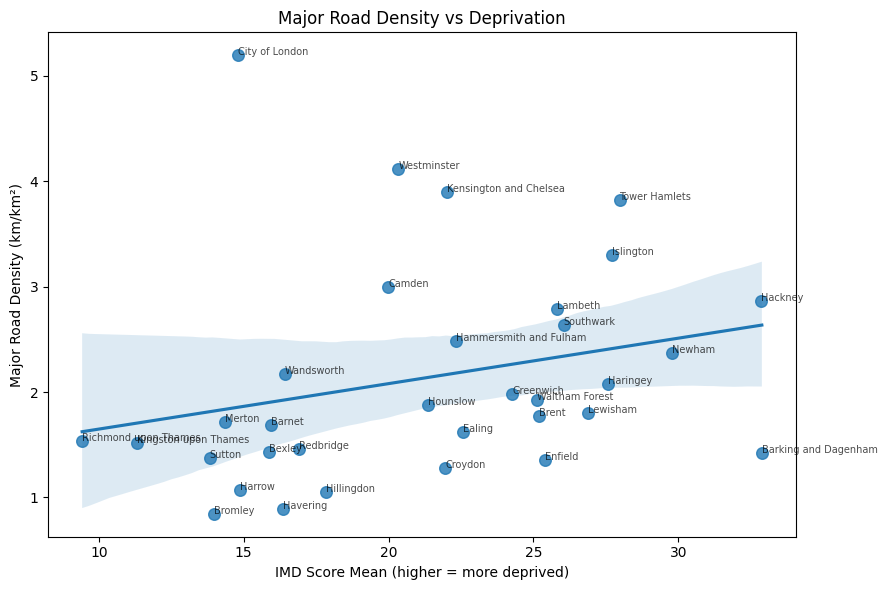

In [47]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="imd_score_mean",
    y="major_road_density_km_per_km2",
    scatter_kws={"s": 70}
)

for _, row in df.iterrows():
    plt.text(
        row["imd_score_mean"],
        row["major_road_density_km_per_km2"],
        row["borough_name"],
        fontsize=7,
        alpha=0.7
    )

plt.xlabel("IMD Score Mean (higher = more deprived)")
plt.ylabel("Major Road Density (km/km²)")
plt.title("Major Road Density vs Deprivation")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_major_road_density_vs_imd.png", dpi=150)
plt.show()